In [1]:
"""
Es este Script vamos a compbinar 4 metodos:
Sobel: calcula la variación de la intensidades horizontales y verticales.
Magnitud gradient: Calcula las vacioariones en x, y usando como input Sobel
Laplancia: calcula las variaciones bruscas en la intensidad.
Canny: Es un metodo mas complejo y usa multiples pasos
"""

'\nEs este Script vamos a compbinar 4 metodos:\nSobel: calcula la variación de la intensidades horizontales y verticales.\nMagnitud gradient: Calcula las vacioariones en x, y usando como input Sobel\nLaplancia: calcula las variaciones bruscas en la intensidad.\nCanny: Es un metodo mas complejo y usa multiples pasos\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pathlib import Path
from skimage.draw import disk, rectangle
from skimage.util import random_noise

In [3]:
"""
Creamos una imagen sintética.

fase de fondo
inclusiones
región rectangular
grietas
desenfoque
ruido

Esto simula un corte tomográfico simplificado.

"""

'\nCreamos una imagen sintética.\n\nfase de fondo\ninclusiones\nregión rectangular\ngrietas\ndesenfoque\nruido\n\nEsto simula un corte tomográfico simplificado.\n\n'

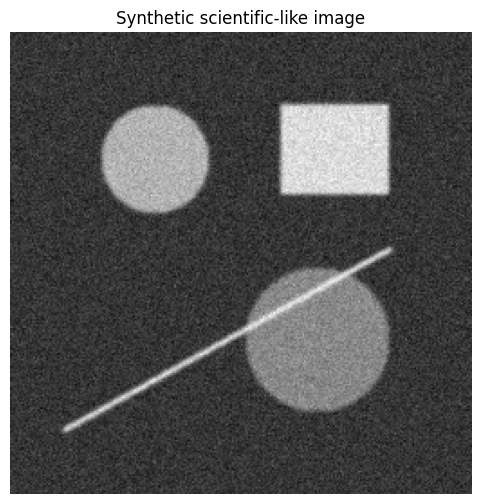

In [4]:
np.random.seed(42)

img = np.ones((256, 256), dtype=np.float32) * 0.25

# Circular inclusions
rr, cc = disk((70, 80), 30, shape=img.shape)
img[rr, cc] = 0.70

rr, cc = disk((170, 170), 40, shape=img.shape)
img[rr, cc] = 0.55

# Rectangular inclusion
rr, cc = rectangle(start=(40, 150), extent=(50, 60), shape=img.shape)
img[rr, cc] = 0.85

# Crack-like feature
cv2.line(img, (30, 220), (210, 120), color=0.95, thickness=2)

# Smooth interfaces slightly
img_blur = cv2.GaussianBlur(img, (5, 5), 0)

# Add noise
img_noisy = random_noise(img_blur, mode="gaussian", var=0.002)
img_noisy = img_noisy.astype(np.float32)

plt.figure(figsize=(6, 6))
plt.imshow(img_noisy, cmap="gray")
plt.title("Synthetic scientific-like image")
plt.axis("off")
plt.show()

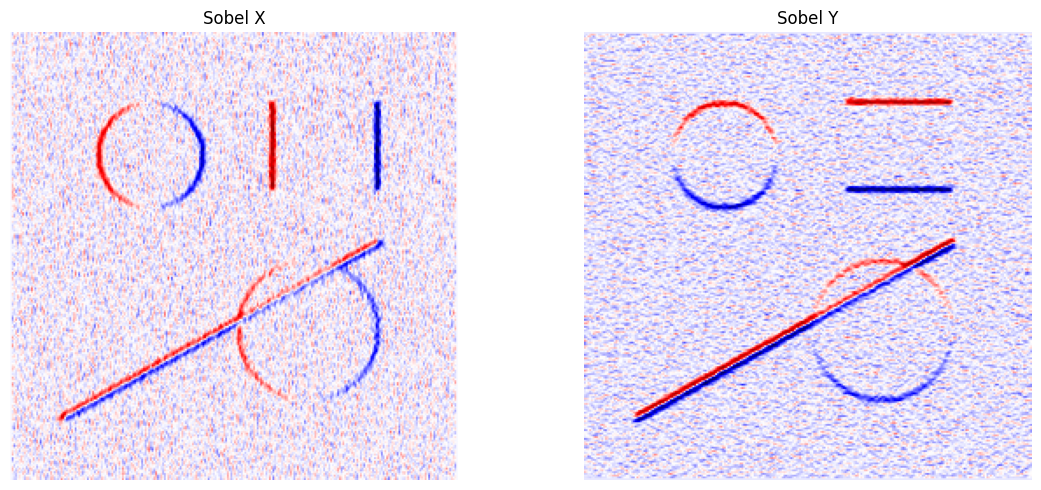

In [6]:
#Calculamos las variaciones verticales y horizontales
sobel_x = cv2.Sobel(img_noisy, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(img_noisy, cv2.CV_64F, dx=0, dy=1, ksize=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(sobel_x, cmap="seismic")
axes[0].set_title("Sobel X")
axes[0].axis("off")

axes[1].imshow(sobel_y, cmap="seismic")
axes[1].set_title("Sobel Y")
axes[1].axis("off")

plt.tight_layout()
plt.show()

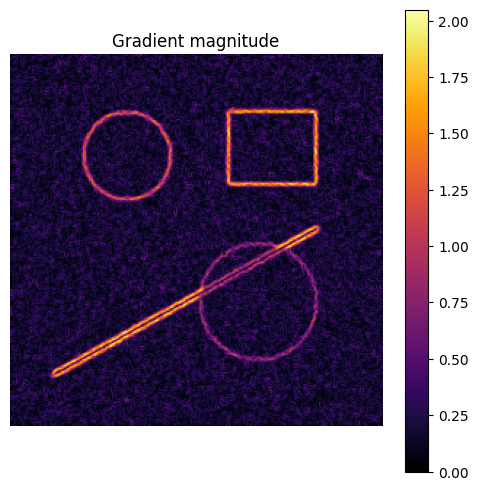

In [7]:
#Calculamos la primera derivada de las variaciones verticales y horizonatles
grad_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.figure(figsize=(6, 6))
plt.imshow(grad_magnitude, cmap="inferno")
plt.title("Gradient magnitude")
plt.axis("off")
plt.colorbar()
plt.show()

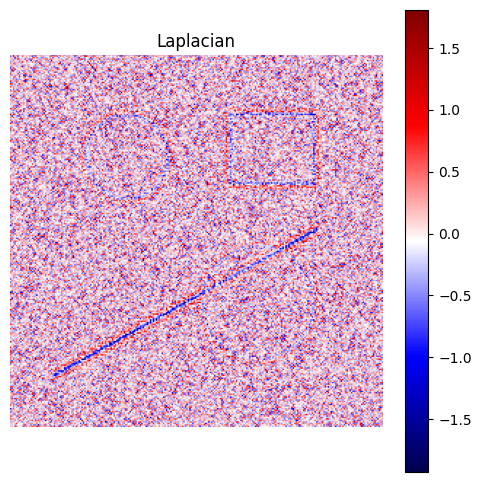

In [12]:
#Calculamos la segunda derivada de las variaciones(Sobel)
laplacian = cv2.Laplacian(img_noisy, cv2.CV_32F, ksize=3)

plt.figure(figsize=(6, 6))
plt.imshow(laplacian, cmap="seismic")
plt.title("Laplacian")
plt.axis("off")
plt.colorbar()
plt.savefig("../figures/figures_sobel_MG_Laplacian_Canny/laplacian_figures.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
"""
Detector de bordes Canny

Canny realiza:
Suavizado
Estimación de gradiente
Supresión de no máximos
Histéresis de doble umbral

Generalmente produce bordes binarios finos y nítidos.

"""


'\nDetector de bordes Canny\n\nCanny realiza:\nSuavizado\nEstimación de gradiente\nSupresión de no máximos\nHistéresis de doble umbral\n\nGeneralmente produce bordes binarios finos y nítidos.\n\n'

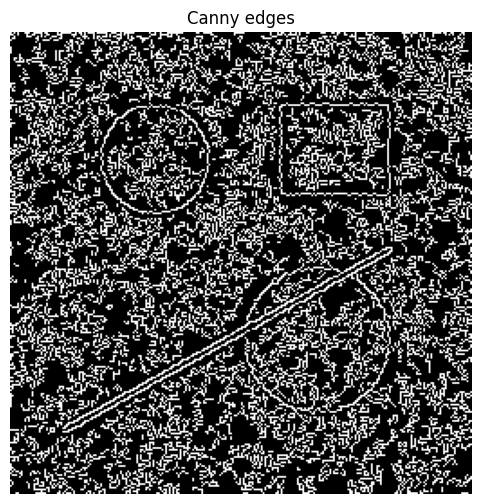

In [14]:
img_uint8 = (img_noisy * 255).astype(np.uint8)

canny_edges = cv2.Canny(img_uint8, threshold1=50, threshold2=120)

plt.figure(figsize=(6, 6))
plt.imshow(canny_edges, cmap="gray")
plt.title("Canny edges")
plt.axis("off")
plt.show()